# H&M Transaction Data 02: Neural Network Purchase Prediction Model
**Purpose**  
The purpose of this notebook is to train a neural network to predict successful purchases of customer-product pairs. Data is loaded from `.pkl` file saved in the previous step.

**Preprocessing**  
Two additional transformations are applied before modeling:
- **Log transform**: right-skewed financial and count features (price, spend, sales volume) are log-transformed with `log1p` to reduce the influence of outliers
- **Standard scaling**: all features are standardized to zero mean and unit variance. The scaler is fit on training data only and applied to validation and test sets to prevent leakage.

**Baseline**  
A majority class classifier is established as a baseline. With a 1:5 positive-to-negative ratio, a classifier that always predicts "no purchase" would achieve 80% accuracy. The baseline F1 score for the positive class is effectively 0, since it never predicts a purchase. The neural network must meaningfully beat this.

**Model Architecture**  
A feedforward neural network with two hidden layers `[128, 32]` and dropout regularization after each layer. The architecture was selected through manual experimentation with different layer sizes and depths. The output layer uses sigmoid activation for binary classification.

**Evaluation Metric**  
F1 score is used as the primary evaluation metric. F1 balances precision and recall and is more informative than accuracy under class imbalance. PR-AUC, precision, and recall are also tracked during training.


In [23]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

import os
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# data processing classes
from src.customer_features import CustomerFeatureEngineer
from src.product_features import ProductFeatureEngineer
from src.recommendation_training import RecommendationTrainingBuilder


## Load Processed Data

In [2]:
# Load data from parquet
data_path = Path("../data")
processed_data_path = data_path / 'processed' / 'product_recommendation'

with open(processed_data_path / 'X_train_base.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open(processed_data_path / 'y_train_base.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open(processed_data_path / 'X_val_base.pkl', 'rb') as f:
    X_val = pickle.load(f)
with open(processed_data_path / 'y_val_base.pkl', 'rb') as f:
    y_val = pickle.load(f)
with open(processed_data_path / 'X_test_base.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open(processed_data_path / 'y_test_base.pkl', 'rb') as f:
    y_test = pickle.load(f)

print(f"{X_train.shape=}")
print(f"{y_train.shape=}")
print(f"{X_val.shape=}")
print(f"{y_val.shape=}")
print(f"{X_test.shape=}")
print(f"{y_test.shape=}")

X_train.shape=(238936, 47)
y_train.shape=(238936,)
X_val.shape=(230262, 47)
y_val.shape=(230262,)
X_test.shape=(221238, 47)
y_test.shape=(221238,)


In [3]:
# Check what data was loaded
print(f"X_train type: {type(X_train)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_train memory: {X_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData types:")
print(X_train.dtypes)

X_train type: <class 'pandas.core.frame.DataFrame'>
X_train shape: (238936, 47)
X_train memory: 85.68 MB

Data types:
garment_Jersey Basic                       int64
garment_Trousers                           int64
age                                      float64
max_price                                float64
avg_days_between_purchases               float64
garment_Under-, Nightwear                  int64
garment_Jersey Fancy                       int64
garment_Dresses Ladies                     int64
garment_Knitwear                           int64
garment_Shirts                             int64
garment_Dresses/Skirts girls               int64
Active                                   float64
garment_Accessories                        int64
avg_transaction_value                    float64
garment_Blouses                            int64
fashion_news_frequency_REGULARLY         float64
garment_Shorts                             int64
garment_Dressed                            int64


## Feature Engineering and Scaling

Before training, two transformations are applied to improve neural network performance.

### Log transform financial features

Several features have heavily right-skewed distributions. A small number of high-value customers or popular products pull the mean far above the median.

`log1p` (i.e., log(1 + x)) is used rather than plain log to safely handle zero values.

Features transformed:
- `avg_price`, `min_price`, `max_price` — product price statistics
- `total_spent` — cumulative customer spend
- `num_purchases` — purchase frequency
- `sales_last_7_days`, `sales_last_30_days` — recent product popularity

In [4]:
cols_to_log = ['avg_price', 'max_price', 'total_spent', 'min_price', 'num_purchases', 'sales_last_7_days', 'sales_last_30_days']

for price_feature in cols_to_log:
    X_train[f"log_{price_feature}"] = np.log1p(X_train[price_feature])
    X_train.drop(columns=[price_feature], inplace=True)
    X_val[f"log_{price_feature}"] = np.log1p(X_val[price_feature])
    X_val.drop(columns=[price_feature], inplace=True)
    X_test[f"log_{price_feature}"] = np.log1p(X_test[price_feature])
    X_test.drop(columns=[price_feature], inplace=True)
    

### Standard Scaler

After log transformation, all features are standardized to zero mean and unit variance using `StandardScaler`.

The scaler is **fit on training data only** to avoid data leakage, and then applied to validation and test sets

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train before scaling - mean: {X_train.mean().mean():.2f}, std: {X_train.std().mean():.2f}")
print(f"X_train after scaling - mean: {X_train_scaled.mean():.2f}, std: {X_train_scaled.std():.2f}")

X_train before scaling - mean: 1.31, std: 1.13
X_train after scaling - mean: 0.00, std: 1.00


## Description of Data

The following charts explore the distribution of key features in the training set after log transformation and scaling. These visualizations informed preprocessing decisions and give context for what the model is working with.

### Correlation Matrix

The heatmap shows pairwise correlations between all features and the target variable (`purchased`). Most of the matrix falls in the mid-range — no single feature is strongly correlated with the outcome, which is expected in a recommendation setting where purchase behavior is driven by a combination of signals. Some garment category dummies show surprising correlations with each other, likely reflecting co-purchase patterns. Overall the heatmap does not provide strong directional guidance, which is part of the motivation for using a neural network — rather than hand-selecting features, we let the model learn which combinations are predictive.

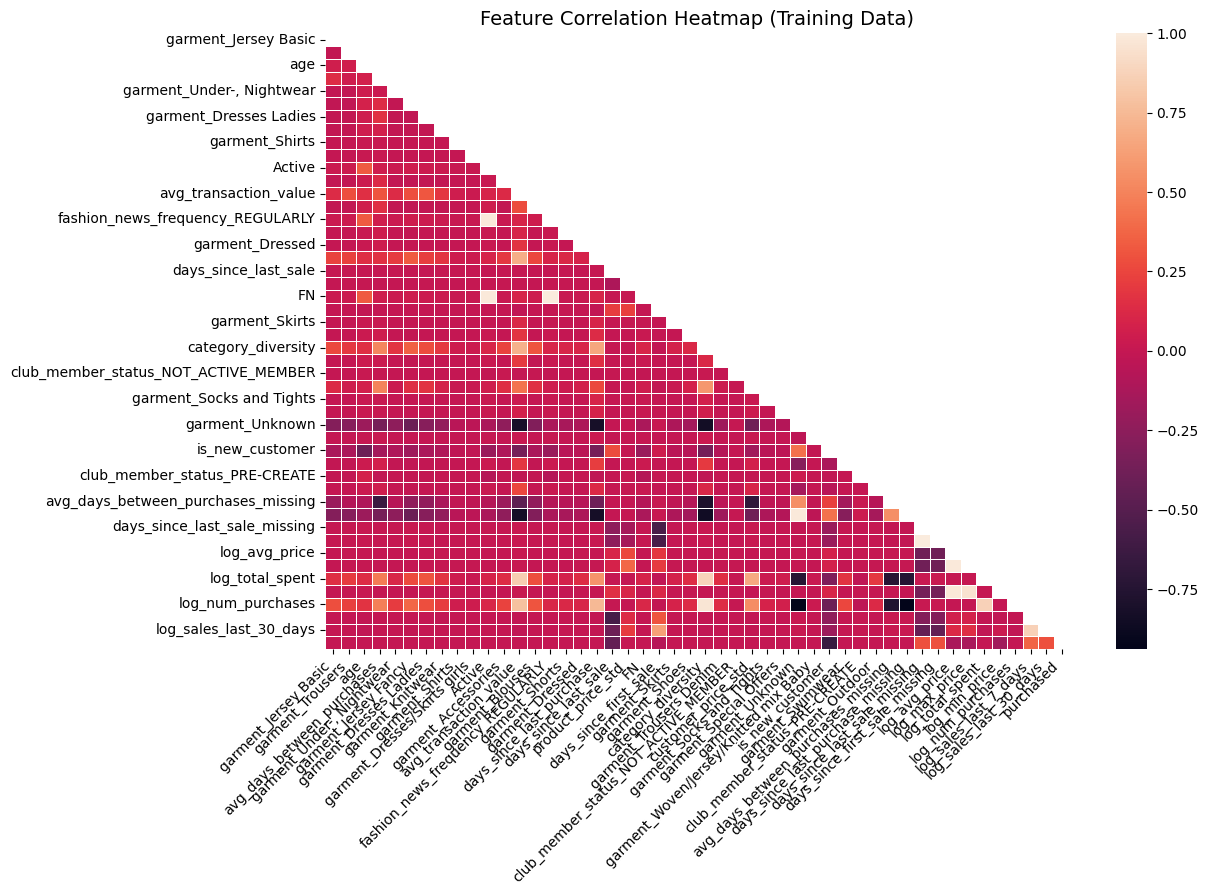

In [6]:
corr = pd.concat([X_train, y_train], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
ax = sns.heatmap(corr,mask=mask,annot=False, linewidths=.5)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Feature Correlation Heatmap (Training Data)', fontsize=14)
plt.show()

### Price Feature Distributions

Log-transformed price features (min, avg, max) are shown here. The raw distributions were heavily right-skewed; applying `log1p` brought them closer to a workable range and resulted in a measurable improvement in model precision and recall during experimentation. After transformation, the three price features cluster closely together near zero, reflecting that most H&M products are similarly priced — min, avg, and max price tend to move together within a product.

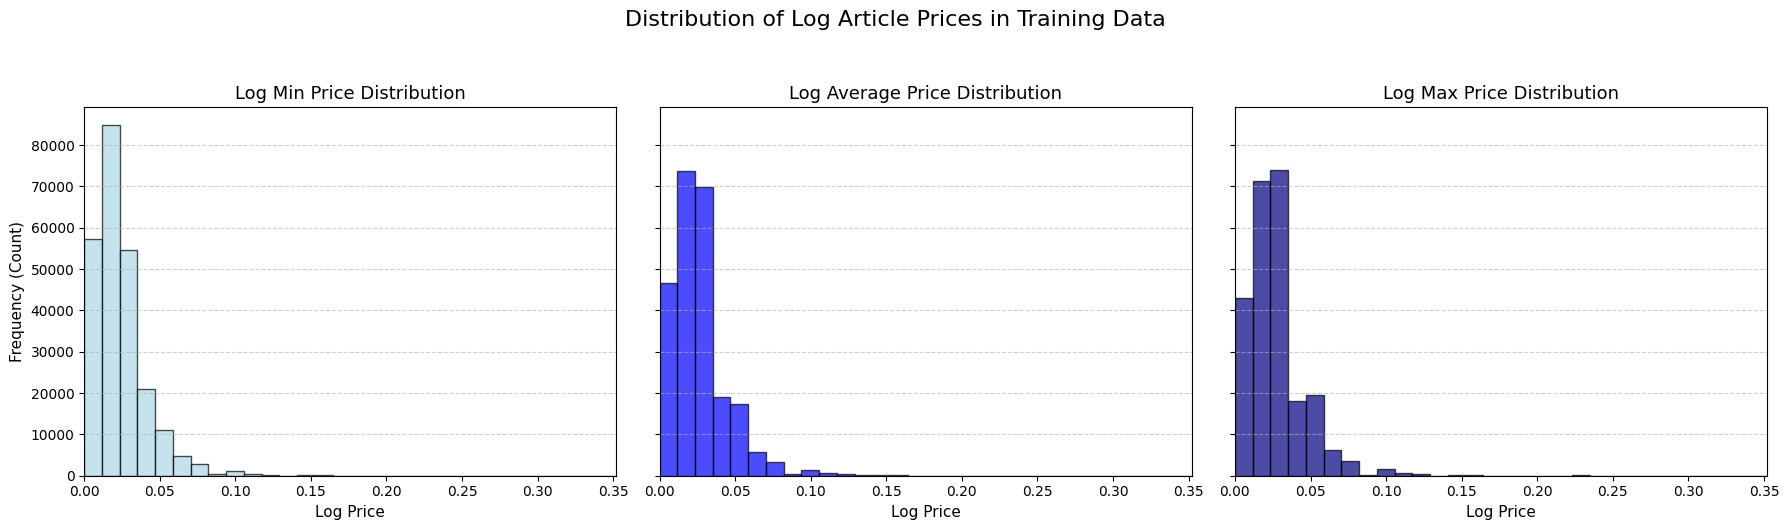

In [7]:
log_price_cols = ['log_min_price', 'log_avg_price', 'log_max_price']
X_train_prices = X_train[log_price_cols].copy()

x_min = X_train_prices.min().min()
x_max = X_train_prices.max().max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = ['Log Min Price Distribution', 'Log Average Price Distribution', 'Log Max Price Distribution']
colors = ['lightblue', 'blue', 'navy']

for i in range(3):
    axes[i].hist(X_train_prices[log_price_cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13)
    axes[i].set_xlabel("Log Price", fontsize=11)
    if i == 0:
        axes[i].set_ylabel("Frequency (Count)", fontsize=11)
    axes[i].set_xlim(x_min, x_max)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
fig.suptitle('Distribution of Log Article Prices in Training Data', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

### Customer Behavior Features

Distributions for number of purchases, total spend, and average days between purchases. These features are heavily dominated by the imputed sentinel value (-1), which was substituted for customers with no purchase history. The distributions themselves are therefore not very informative in isolation. The intent is that the model uses the accompanying binary indicator columns (e.g., `days_since_last_purchase_missing`) to differentiate between customers with real history and those without, and finds meaning in the correlation between those flags and the outcome.

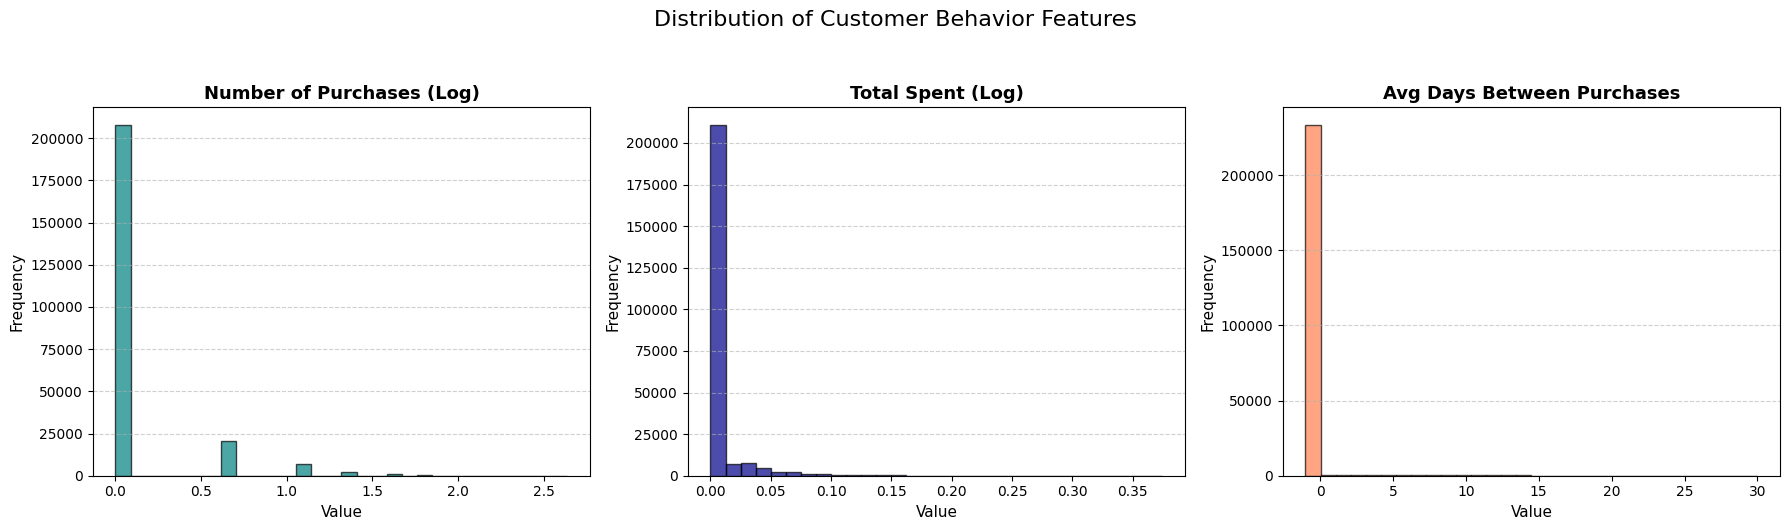

In [8]:
cols = ['log_num_purchases', 'log_total_spent', 'avg_days_between_purchases']
titles = ['Number of Purchases (Log)', 'Total Spent (Log)', 'Avg Days Between Purchases']
colors = ['teal', 'darkblue', 'coral']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    axes[i].hist(X_train[cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Distribution of Customer Behavior Features', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Product Sales Distribution

7-day and 30-day log sales distributions reveal an interesting pattern: in the 7-day window, the most common value is 0 — many products see no sales in any given week. In the 30-day window, the distribution shifts and most products have at least some sales. This suggests these two features capture different signals: 7-day sales reflects short-term momentum (is this product trending right now?) while 30-day sales reflects longer-term sustained demand. Together they give the model a sense of both recency and consistency of product popularity.

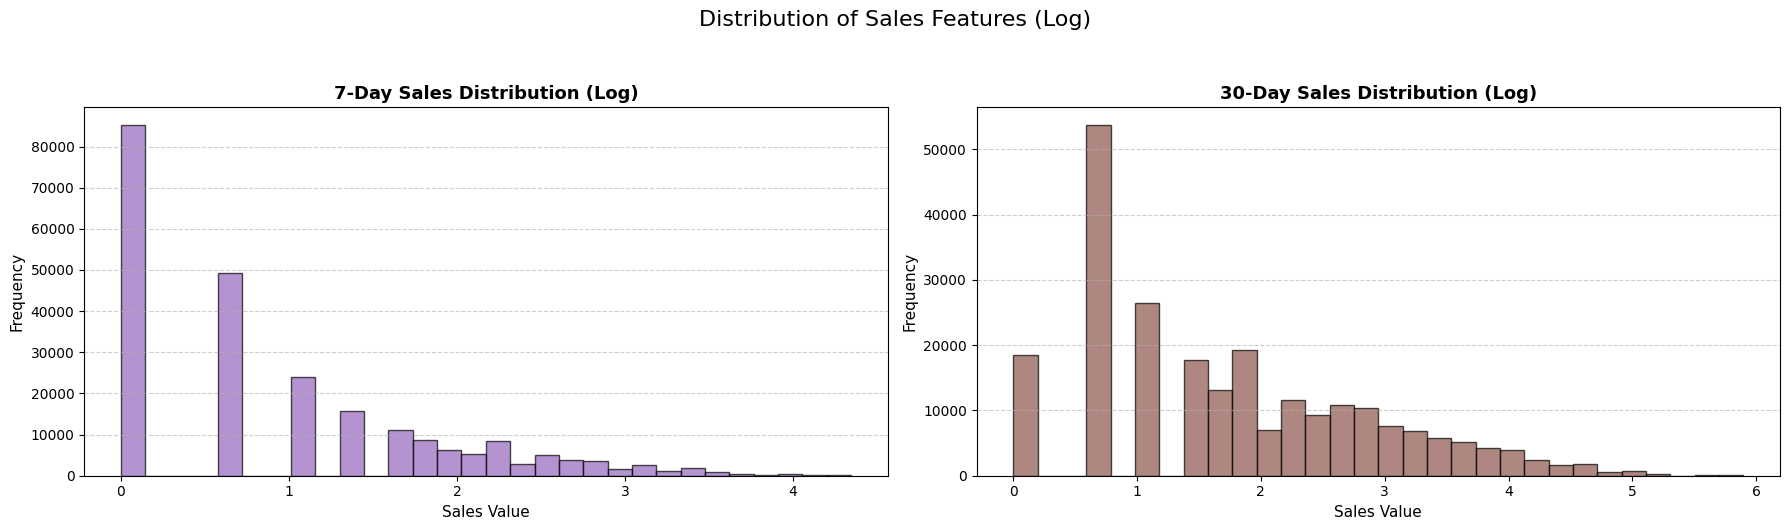

In [9]:
sales_cols = ['log_sales_last_7_days', 'log_sales_last_30_days']
titles = [ '7-Day Sales Distribution (Log)', '30-Day Sales Distribution (Log)']
colors = [ '#9467bd', '#8c564b']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for i in range(2):
    axes[i].hist(X_train[sales_cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Sales Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Distribution of Sales Features (Log)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## Model building

Build a neural net model with variable number of hidden layers.

- num_features: number of features in dataset
- hidden_layer_sizes: variable array of nodes in hidden layers of neural net
- learning_rate: hyperparameter learning rate
- activation: activation function used within hidden layers
- optimizer: Adam or SGD optimizer

Uses sigmoid activation for the final layer. Reports accuracy.

In [10]:
class MajorityClassifier:  
    def fit(self, X, y):
        y_actual = self._y_actual(y)
        
        self.majority = y_actual.mode()[0]
        self.majority_probability = (y_actual == self.majority).mean()
        self.class_probabilities = y_actual.value_counts(normalize=True).sort_index()
        self.classes = self.class_probabilities.index.to_list()

    def predict(self, X):
        return np.full(len(X), self.majority)

    def evaluate(self, X, y):
        prediction = self.predict(X)
        actual = self._y_actual(y)
        accuracy = (prediction == actual).mean()
        return {'accuracy': accuracy}

    def log_loss(self, y):
        y_actual = self._y_actual(y)
        
        predicted_probabilities = np.tile(self.class_probabilities.values, (len(y), 1))
        
        y_one_hot = np.zeros((len(y), len(self.classes)))
        for i, val in enumerate(y_actual):
            class_idx = self.classes.index(val)
            y_one_hot[i, class_idx] = 1 
        
        log_p = np.log(np.clip(predicted_probabilities, 1e-15, 1))
        return -np.sum(y_one_hot * log_p) / len(y)
    
    def _y_actual(self, y):
        return y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y

In [11]:
baseline = MajorityClassifier()
baseline.fit(X_train_scaled, y_train)

print(f"Baseline predictions: Always predict {baseline.majority}")
print(f"Training accuracy: {baseline.evaluate(X_train_scaled, y_train)['accuracy']:.4f}")
print(f"Training loss: {baseline.log_loss(y_train):.4f}")

print(f"Validation accuracy: {baseline.evaluate(X_val_scaled, y_val)['accuracy']:.4f}")
print(f"Validation loss: {baseline.log_loss(y_val):.4f}")

Baseline predictions: Always predict 0
Training accuracy: 0.5000
Training loss: 0.6931
Validation accuracy: 0.8333
Validation loss: 0.6931


In [16]:
def build_recommendation_model(num_features,
                                hidden_layer_sizes=[512],
                                learning_rate=0.001,
                                activation='relu',
                                optimizer="Adam"):
    tf.keras.backend.clear_session()
    tf.random.set_seed(67)

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(num_features,)))
    for i, layer_units in enumerate(hidden_layer_sizes):
        layer = tf.keras.layers.Dense(
            units=layer_units,
            use_bias=True,
            activation=activation,
            kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
            bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
        )
        model.add(layer)
        model.add(tf.keras.layers.Dropout(0.5))
    
    model.add(tf.keras.layers.Dense(
        units=1,
        use_bias=True,
        activation='sigmoid',
        kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
        )
    )

    if optimizer == "SGD":
        keras_optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "Adam":
        keras_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        keras_optimizer = optimizer

    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer=keras_optimizer,
        metrics=[
            tf.keras.metrics.F1Score(name='f1', average='macro', threshold=0.5),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,305 (40.25 KB)

 Trainable params: 10,305 (40.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
3734/3734 ━━━━━━━━━━━━━━━━━━━━ 58s 15ms/step - f1: 0.8791 - loss: 0.3261 - pr_auc: 0.9410 - precision: 0.8944 - recall: 0.8643 - val_f1: 0.6387 - val_loss: 0.4948 - val_pr_auc: 0.6481 - val_precision: 0.4989 - val_recall: 0.8875
Epoch 2/4
3734/3734 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - f1: 0.8811 - loss: 0.3657 - pr_auc: 0.9357 - precision: 0.8942 - recall: 0.8683 - val_f1: 0.6941 - val_loss: 0.3139 - val_pr_auc: 0.8488 - val_precision: 0.5772 - val_recall: 0.8703
Epoch 3/4
3734/3734 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - f1: 0.8792 - loss: 0.4020 - pr_auc: 0.9307 - precision: 0.8903 - recall: 0.8685 - val_f1: 0.7118 - val_loss: 0.3091 - val_pr_auc: 0.8529 - val_precision: 0.6091 - val_recall: 0.8563
Epoch 4/4
3734/3734 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - f1: 0.8778 - loss: 0.4268 - pr_auc: 0.9282 - precision: 0.8888 - recall: 0.8670 - val_f1: 0.6840 - val_loss: 0.3763 - val_pr_auc: 0.8075 - val_precision: 0.5608 - val_recall: 0.8768


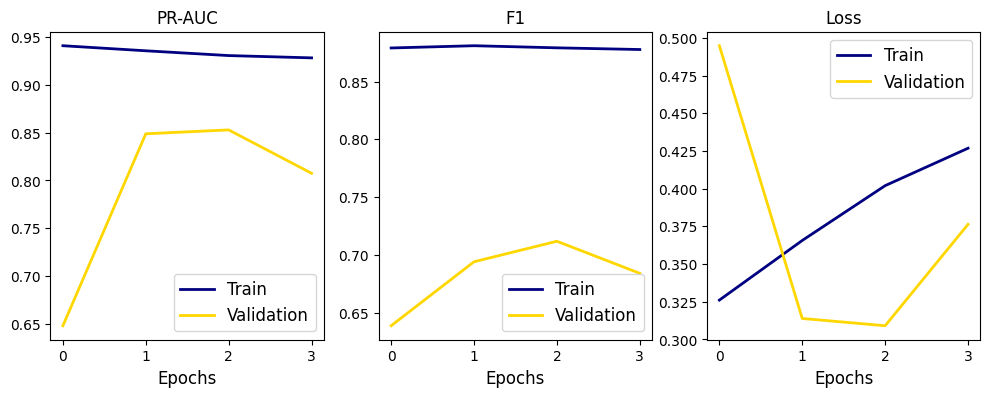

In [17]:

model = build_recommendation_model(X_train_scaled.shape[1],
                                    hidden_layer_sizes=[128,32],
                                    learning_rate=0.001,
                                    activation='relu',
                                    optimizer="Adam")
model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_f1',
    patience=3,
    mode='max',
    restore_best_weights=True
)

history = model.fit(X_train_scaled, y_train,
                    validation_data=(X_val_scaled, y_val),
                    epochs=4,
                    batch_size=64,
                    callbacks=[early_stopping],
                    verbose=1)

history=history.history
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history['pr_auc'], lw=2, color='navy')
plt.plot(history['val_pr_auc'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('PR-AUC', size=12)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history['f1'], lw=2, color='navy')
plt.plot(history['val_f1'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('F1', size=12)


ax = fig.add_subplot(1, 3, 3)
plt.plot(history['loss'], lw=2, color='navy')
plt.plot(history['val_loss'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('Loss', size=12)

plt.show()

## Test Data

In [ ]:
test_loss, test_f1, test_pr_auc, test_precision, test_recall = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"====== FINAL MODEL EVALUATION ======")
print(f"\nNeural Network Results:")
print(f"  Test Loss:      {test_loss:.4f}")
print(f"  Test F1:        {test_f1:.4f}")
print(f"  Test PR-AUC:    {test_pr_auc:.4f}")
print(f"  Test Precision: {test_precision:.4f}")
print(f"  Test Recall:    {test_recall:.4f}")

## Confusion Matrix

In [ ]:
PURCHASE = "Purchase"
NO_PURCHASE = "No Purchase"
LABELS = [NO_PURCHASE, PURCHASE]

probability_threshold = 0.5

predictions = model.predict(x=X_test_scaled) > probability_threshold
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=LABELS)
disp.plot()
plt.title("Confusion Matrix for Test Data")
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test.values, predictions, target_names=LABELS))


In [ ]:
true_neg, false_pos, false_neg, true_pos = cm.ravel()
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)


print(f"  True Negatives:  {true_neg:,} (correctly predicted no purchase)")
print(f"  False Positives: {false_pos:,} (predicted purchase, but didn't buy)")
print(f"  False Negatives: {false_neg:,} (predicted no purchase, but did buy)")
print(f"  True Positives:  {true_pos:,} (correctly predicted purchase)")
print(f"\n")
print(f"  Precision: {precision:.2%} (of {(true_pos + false_pos):,} predicted purchases, how many were correct)")
print(f"  Recall:    {recall:.2%} (of {(true_pos + false_neg):,} actual purchases, how many did we catch)")

# Subgroup Analysis

